### **Problem Statement**

In [156]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [157]:
Sheets = pd.read_excel(r"C:\Users\ankus\OneDrive\Desktop\SDE+DATA\DATA\Projects\Sales DA (python+powerBI) end to end\Regional Sales Dataset.xlsx", sheet_name=None)

### Assigning Dataframe to Sheets

In [158]:
# Assigning each sheet to a different dataframe
df_sales = Sheets['Sales Orders']
df_products = Sheets['Products']
df_customers = Sheets['Customers']
df_regions = Sheets['Regions']
df_state_reg = Sheets['State Regions']
df_budgets = Sheets['2017 Budgets']


In [159]:
print(f"df_sales      shape: {df_sales.shape}      # Sales Orders")
print(f"df_customers  shape: {df_customers.shape}  # Customers")
print(f"df_products   shape: {df_products.shape}   # Products")
print(f"df_regions    shape: {df_regions.shape}    # Regions")
print(f"df_state_reg  shape: {df_state_reg.shape}  # State Regions")
print(f"df_budgets    shape: {df_budgets.shape}    # 2017 Budgets")

df_sales      shape: (64104, 12)      # Sales Orders
df_customers  shape: (175, 2)  # Customers
df_products   shape: (30, 2)   # Products
df_regions    shape: (994, 15)    # Regions
df_state_reg  shape: (49, 3)  # State Regions
df_budgets    shape: (30, 2)    # 2017 Budgets


### Checking Data

In [160]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


### 
In df_state_reg, column name was included in data

In [161]:
df_state_reg.columns = df_state_reg.iloc[0]
df_state_reg = df_state_reg.drop(0).reset_index(drop=True)
df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [162]:
# Checking for null values

df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

### **Data Cleaning**

In [163]:
# merge df_sales and df_customers on Customer Index

df = df_sales.merge(df_customers, left_on='Customer Name Index', right_on='Customer Index', how='left')

In [164]:
# merge df and df_products on Product Description Index

df = df.merge(df_products, left_on='Product Description Index', right_on='Index', how='left')

In [165]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [166]:
# merge df and df_regions on Delivery Region Index

df = df.merge(df_regions, left_on='Delivery Region Index', right_on='id', how='left')

In [167]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [168]:
# merge df and df_state_reg on state_code

df = df.merge(df_state_reg[["State Code","Region"]], left_on='state_code', right_on='State Code', how='left')

In [169]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [170]:
# merge df and df_budgets on Product name

df = df.merge(df_budgets, left_on='Product Name', right_on='Product Name', how='left')

In [171]:
# removing the repeted columns

df=df.drop(columns=['Customer Index', 'Index','id', 'State Code'])

In [172]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [173]:
# Converting all the column names to lower case

df.columns = df.columns.str.lower()

In [174]:
df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [175]:
# rename column in snake_case

df = df.rename(columns={
    'ordernumber'      : 'order_number',   # unique order identifier
    'orderdate'        : 'order_date',     # date of the order
    'customer name index' : 'customer_name_index',  # index to customer table
    'currency code'     : 'currency_code',  # currency of the order
    'warehouse code'    : 'warehouse_code', # warehouse fulfilling the order
    'delivery region index' : 'delivery_region_index', # index to regions table
    'product description index' : 'product_description_index', # index to products table
    'customer names'   : 'customer_name',  # customer who placed it
    'product name'     : 'product_name',   # product sold
    'order quantity'   : 'quantity',       # units sold
    'unit price'       : 'unit_price',     # price per unit in USD
    'line total'       : 'revenue',        # revenue for the line item
    'total unit cost'  : 'cost',           # cost for the line item
    'state_code'       : 'state',          # two-letter state code
    'state'            : 'state_name',     # full state name
    'region'           : 'us_region',      # broader U.S. region
    'latitude'         : 'lat',            # latitude (float)
    'longitude'        : 'lon',            # longitude (float)
    '2017 budgets'     : 'budget'          # 2017 budget target (float)
})

df.head()

,order_number,order_date,customer_name_index,channel,currency_code,warehouse_code,delivery_region_index,product_description_index,quantity,unit_price,...,lon,area_code,population,households,median_income,land_area,water_area,time_zone,us_region,budget
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [176]:
# Since, budget is only for year 2017, so blank budget for other years

df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

df.head()

,order_number,order_date,customer_name_index,channel,currency_code,warehouse_code,delivery_region_index,product_description_index,quantity,unit_price,...,lon,area_code,population,households,median_income,land_area,water_area,time_zone,us_region,budget
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,NaN
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,NaN
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,NaN
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,NaN
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,NaN


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   order_number               64104 non-null  object        
 1   order_date                 64104 non-null  datetime64[ns]
 2   customer_name_index        64104 non-null  int64         
 3   channel                    64104 non-null  object        
 4   currency_code              64104 non-null  object        
 5   warehouse_code             64104 non-null  object        
 6   delivery_region_index      64104 non-null  int64         
 7   product_description_index  64104 non-null  int64         
 8   quantity                   64104 non-null  int64         
 9   unit_price                 64104 non-null  float64       
 10  revenue                    64104 non-null  float64       
 11  cost                       64104 non-null  float64       
 12  cust

In [178]:
df_2017 = df[df['order_date'].dt.year == 2017]

In [179]:
df_2017.head()

,order_number,order_date,customer_name_index,channel,currency_code,warehouse_code,delivery_region_index,product_description_index,quantity,unit_price,...,lon,area_code,population,households,median_income,land_area,water_area,time_zone,us_region,budget
46363,SO - 0002544,2017-01-01,107,Wholesale,USD,NXH382,711,30,6,1239.5,...,-74.02375,551,69156,23029,41107,3333346,0,America/New York,Northeast,1011609.684
46364,SO - 0006431,2017-01-01,116,Wholesale,USD,NXH382,234,13,5,1829.1,...,-108.55065,970,60358,24290,45358,101735554,921925,America/Denver,West,3720639.645
46365,SO - 0007491,2017-01-01,45,Wholesale,USD,NXH382,108,15,9,2412.0,...,-118.35313,424,111666,36667,42044,23485845,63502,America/Los Angeles,West,3299478.315
46366,SO - 0008741,2017-01-01,169,Wholesale,USD,GUT930,375,8,8,904.5,...,-90.66457,563,58799,23901,47450,78952077,2802123,America/Chicago,Midwest,1085037.329
46367,SO - 0009295,2017-01-01,20,Wholesale,USD,NXH382,339,2,12,1112.2,...,-82.52546,352,100270,39038,41308,154983928,6194314,America/New York,South,3050087.565


In [180]:
df.columns.values

array(['order_number', 'order_date', 'customer_name_index', 'channel',
       'currency_code', 'warehouse_code', 'delivery_region_index',
       'product_description_index', 'quantity', 'unit_price', 'revenue',
       'cost', 'customer_name', 'product_name', 'name', 'county', 'state',
       'state_name', 'type', 'lat', 'lon', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area',
       'time_zone', 'us_region', 'budget'], dtype=object)

### **Feature engineering**

In [181]:
df['total_cost'] = df['cost'] * df['quantity']
df['profit'] = df['revenue'] - df['total_cost']
df['profit_margin_pct'] = df['profit'] / df['revenue'] * 100

In [182]:
df.head()

,order_number,order_date,customer_name_index,channel,currency_code,warehouse_code,delivery_region_index,product_description_index,quantity,unit_price,...,households,median_income,land_area,water_area,time_zone,us_region,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,52798,36466,268318796,13908113,America/New York,South,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,26020,124759,62489257,386195,America/Los Angeles,West,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,24141,63158,70972793,720300,America/New York,Northeast,NaN,10082.160,8249.040,45.0


### ***Exploratory Data Analysis (EDA)***

### 1. Monthly Sales Trend

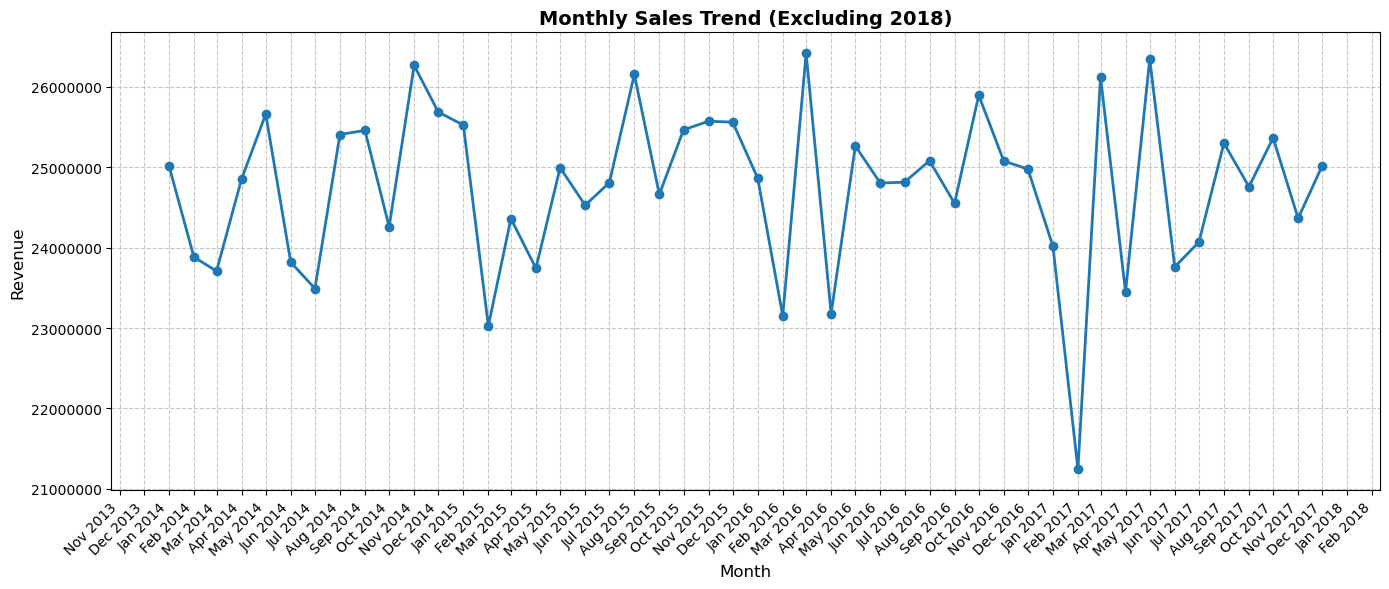

In [183]:
from matplotlib.dates import MonthLocator, DateFormatter

# 1. Assuming your dataframe is called 'df'
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Filter out year 2018
df_filtered = df[df['order_date'].dt.year != 2018].copy()

# 3. Group by month and sum revenue
monthly_sales = (
    df_filtered
    .groupby(df_filtered['order_date'].dt.to_period('M'))['revenue']
    .sum()
    .reset_index()
)

# Convert period back to datetime for plotting
monthly_sales['order_date'] = monthly_sales['order_date'].dt.to_timestamp()

# ── Plotting ───────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 6))

plt.plot(monthly_sales['order_date'], 
         monthly_sales['revenue'],
         marker='o', 
         linewidth=2,
         color='#1f77b4')

plt.title('Monthly Sales Trend (Excluding 2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)

# Show every month
plt.gca().xaxis.set_major_locator(MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(DateFormatter('%b %Y'))

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.grid(True, linestyle='--', alpha=0.7, axis='x')

# Better number formatting (optional)
plt.ticklabel_format(style='plain', axis='y')
# Alternative for commas: 
# from matplotlib.ticker import FuncFormatter
# plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### 2. Monthly Sales trend of all years

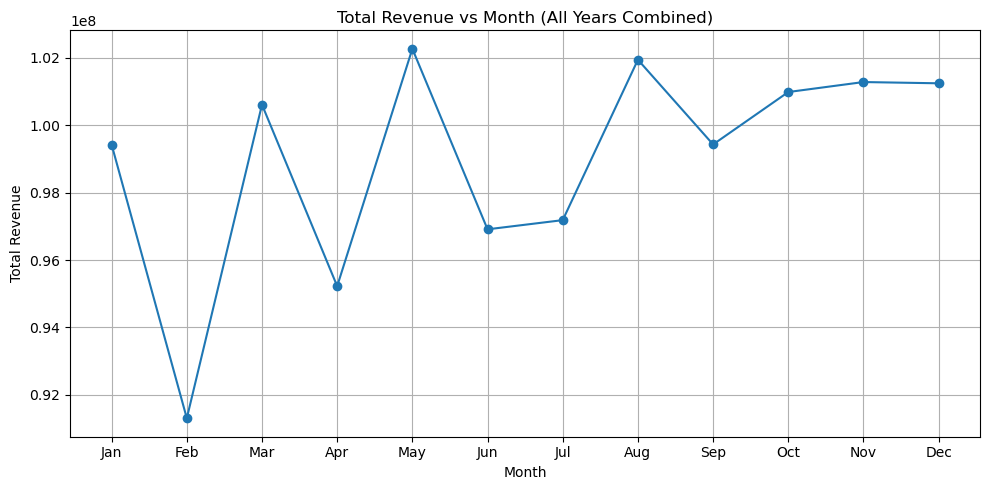

In [184]:
df_filtered['month'] = df['order_date'].dt.month

monthly_revenue = (
    df_filtered.groupby('month')['revenue']
      .sum()
      .reset_index()
      .sort_values('month')
)

monthly_revenue['month_name'] = monthly_revenue['month'].apply(
    lambda x: pd.to_datetime(str(x), format='%m').strftime('%b')
)

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_revenue['month_name'],
    monthly_revenue['revenue'],
    marker='o'
)

plt.title('Total Revenue vs Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()



In [185]:
df.columns.values

array(['order_number', 'order_date', 'customer_name_index', 'channel',
       'currency_code', 'warehouse_code', 'delivery_region_index',
       'product_description_index', 'quantity', 'unit_price', 'revenue',
       'cost', 'customer_name', 'product_name', 'name', 'county', 'state',
       'state_name', 'type', 'lat', 'lon', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area',
       'time_zone', 'us_region', 'budget', 'total_cost', 'profit',
       'profit_margin_pct'], dtype=object)

### 3. Top 10 products in terms of revenue

C:\Users\ankus\AppData\Local\Temp\ipykernel_39532\130576864.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


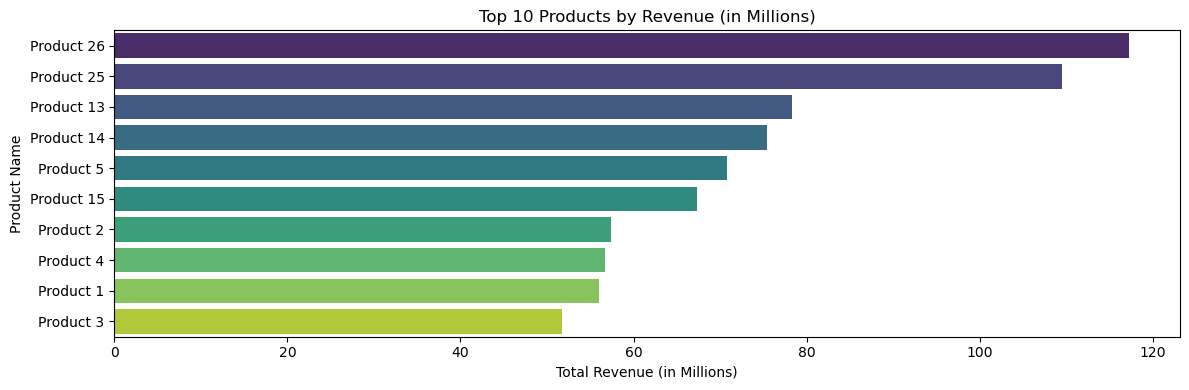

In [186]:
top_prod = df.groupby('product_name')['revenue'].sum()/1000000

top_prod = top_prod.nlargest(10)

plt.figure(figsize=(12, 4))

# Plot a horizontal bar chart: x-axis as revenue in millions, y-axis as product names
sns.barplot(
    x=top_prod.values,    # X-axis: revenue values in millions
    y=top_prod.index,     # Y-axis: product names
    palette='viridis'     # Color palette for bars
)

# Add title and axis labels
plt.title('Top 10 Products by Revenue (in Millions)')  # Main title
plt.xlabel('Total Revenue (in Millions)')              # X-axis label
plt.ylabel('Product Name')                             # Y-axis label

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()
     

### 4. Bottom 10 products interms of revenue

C:\Users\ankus\AppData\Local\Temp\ipykernel_39532\3973283710.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


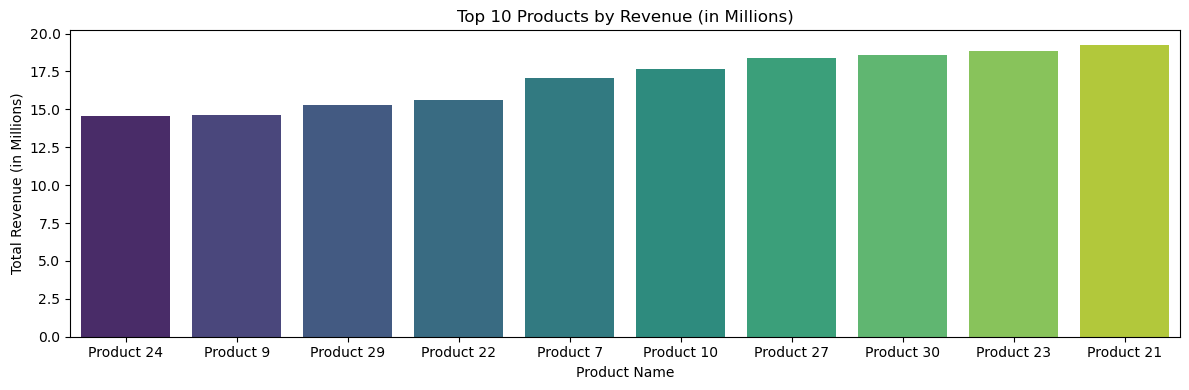

In [187]:
top_prod = df.groupby('product_name')['revenue'].sum()/1000000

top_prod = top_prod.nsmallest(10)

plt.figure(figsize=(12, 4))

# Plot a horizontal bar chart: x-axis as revenue in millions, y-axis as product names
sns.barplot(
    y=top_prod.values, 
    x=top_prod.index,     
    palette='viridis'     
)

# Add title and axis labels
plt.title('Top 10 Products by Revenue (in Millions)')  # Main title
plt.ylabel('Total Revenue (in Millions)')              # X-axis label
plt.xlabel('Product Name')                             # Y-axis label

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()

### 5. Top 10 Products by Avg Profit Margin

C:\Users\ankus\AppData\Local\Temp\ipykernel_39532\2126466113.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


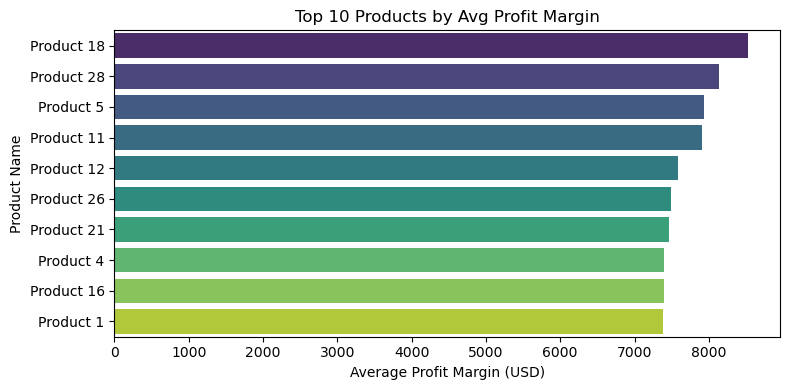

In [188]:
top_avg_margin = df.groupby('product_name')['profit'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))

sns.barplot(
    x=top_avg_margin.values, 
    y=top_avg_margin.index, 
    palette='viridis'     
)

plt.title('Top 10 Products by Avg Profit Margin') 
plt.xlabel('Average Profit Margin (USD)')        
plt.ylabel('Product Name')                        

plt.tight_layout()
plt.show()

### 5. Sales by Channel (Pie Chart)

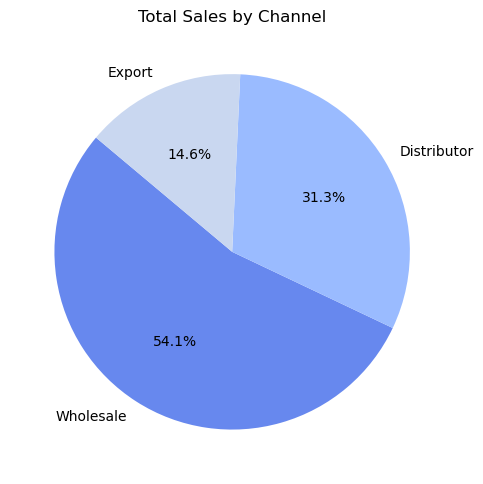

In [189]:
sales_by_channel = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(5,5))

plt.pie(
    sales_by_channel.values,                   # Data: revenue values per channel
    labels=sales_by_channel.index,             # Labels: channel names
    autopct='%1.1f%%',                   # Display percentages with one decimal
    startangle=140,                      # Rotate chart so first slice starts at 140 degrees
    colors=sns.color_palette('coolwarm') # Color palette for slices
)

# Add title for context
plt.title('Total Sales by Channel')

# Adjust layout to ensure everything fits well
plt.tight_layout()

# Display the chart
plt.show()

### 6. Average Order Value (AOV) Distribution

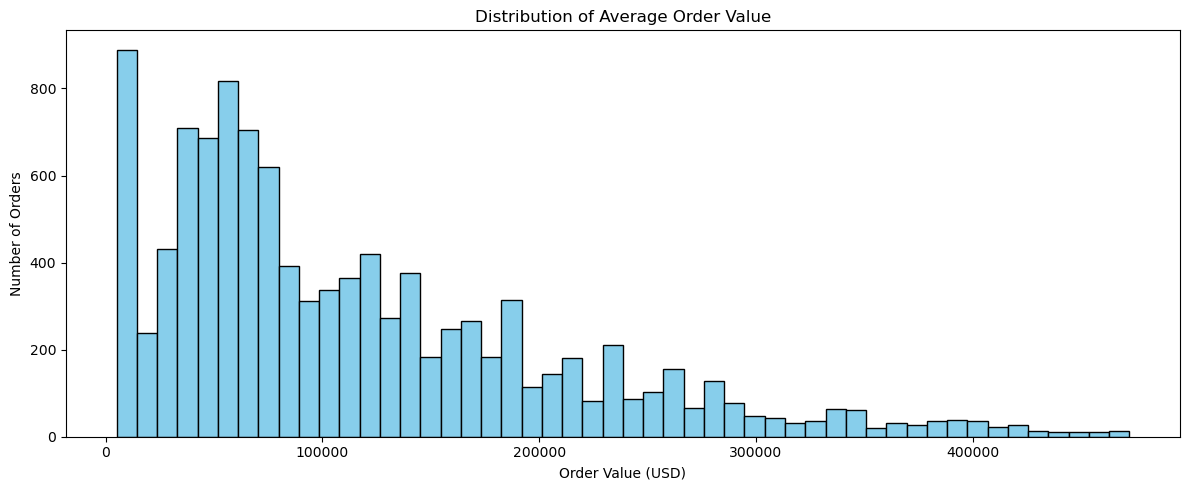

In [190]:
aov = df.groupby('order_number')['revenue'].sum()

plt.figure(figsize=(12, 5))

plt.hist(
    aov,               # Data: list of order values
    bins=50,           # Number of bins to group order values
    color='skyblue',   # Fill color of the bars
    edgecolor='black'  # Outline color of the bars
)

# Add title and axis labels for context
plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

### 7. Profit Margin % vs. Unit Price

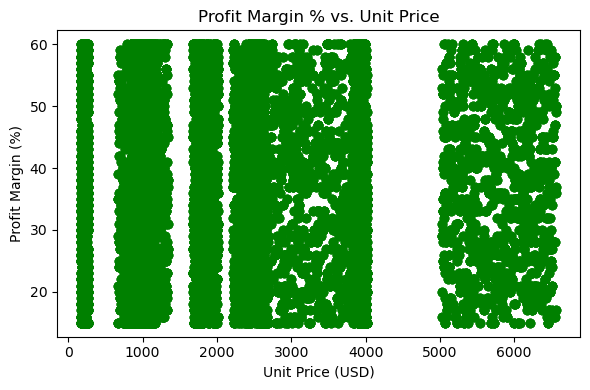

In [191]:
plt.figure(figsize=(6,4))

# Plot unit price vs. profit margin percentage
plt.scatter(
    df['unit_price'],            # X-axis: unit price in USD
    df['profit_margin_pct'],     # Y-axis: profit margin percentage
    alpha=0.6,                   # Transparency level for overlapping points
    color='green'                # Point color
)

# Add title and axis labels
plt.title('Profit Margin % vs. Unit Price')  # Chart title
plt.xlabel('Unit Price (USD)')                # X-axis label
plt.ylabel('Profit Margin (%)')               # Y-axis label

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()

### 8. Unit Price Distribution per Product

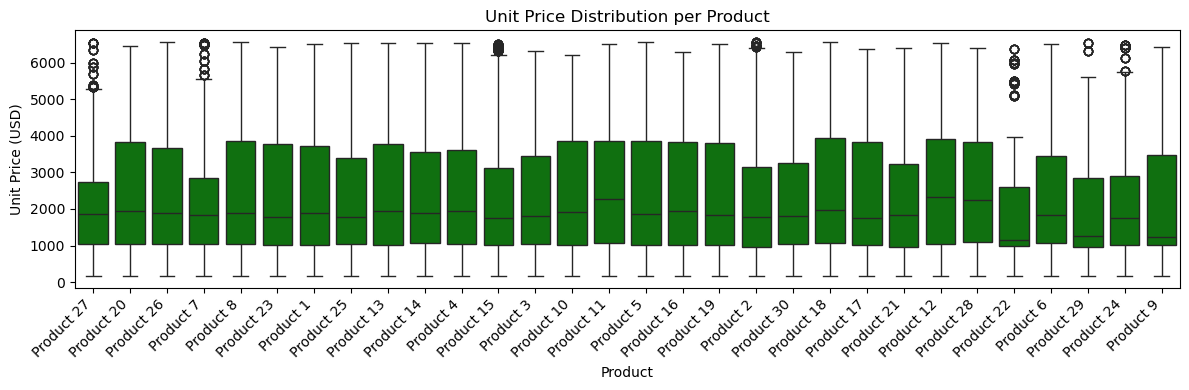

In [192]:
plt.figure(figsize=(12,4))

# Create a boxplot of unit_price by product_name
sns.boxplot(
    data=df,
    x='product_name',   # X-axis: product categories
    y='unit_price',      # Y-axis: unit price values
    color='g'            # Box color
)

# Add title and axis labels
plt.title('Unit Price Distribution per Product')  # Chart title
plt.xlabel('Product')                              # X-axis label
plt.ylabel('Unit Price (USD)')                     # Y-axis label

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the plot
plt.show()

### 9. Total Sales by US Region

C:\Users\ankus\AppData\Local\Temp\ipykernel_39532\152268850.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


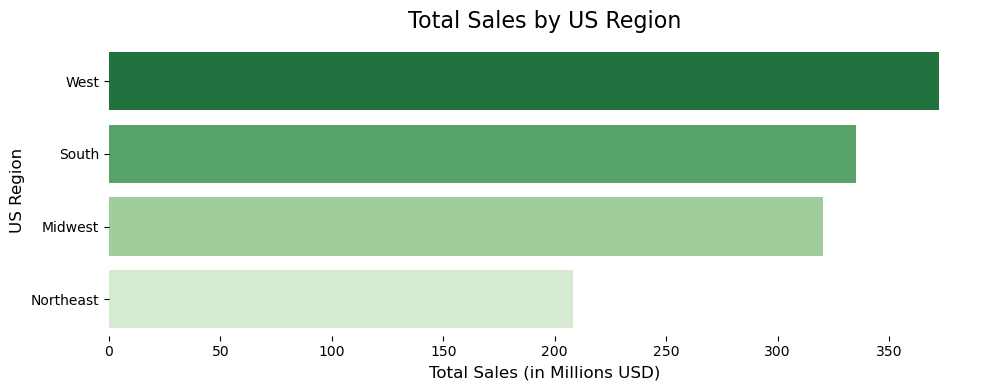

In [193]:
sales_by_us_region = df.groupby('us_region')['revenue'].sum().sort_values(ascending=False)/1000000

plt.figure(figsize=(10, 4))
sns.barplot(
    x=sales_by_us_region.values,
    y=sales_by_us_region.index,
    palette='Greens_r'          # dark→light green
)

# 3. Formatting
plt.title('Total Sales by US Region', fontsize=16, pad=12)
plt.xlabel('Total Sales (in Millions USD)', fontsize=12)
plt.ylabel('US Region', fontsize=12)
plt.xticks(rotation=0)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### 10. Total Sales by State (Choropleth Map)

In [210]:
import plotly.express as px

# 1. Aggregate revenue by state (in millions)
state_sales = df.groupby('state')['revenue'].sum().reset_index()

# state_sales['revenue_m'] = state_sales['revenue'] / 1e6  # convert to millions

# 2. Plotly choropleth
fig = px.choropleth(
    state_sales,
    locations='state',            # column with state codes
    locationmode='USA-states',    # tells Plotly these are US states
    color='revenue',
    scope='usa',
    labels={'revenue':'Total Sales'},
    color_continuous_scale='Blues',
    hover_data={'revenue':':.2f'}  # show 2 decimals
)

# 3. Layout tuning
fig.update_layout(
    title_text='Total Sales by State',
    margin=dict(l=0, r=0, t=40, b=0),
    coloraxis_colorbar=dict(
        title='Sales',
        ticksuffix='M'
    )
)

fig.show()

### 11. Top 10 States by Revenue and Order Count

C:\Users\ankus\AppData\Local\Temp\ipykernel_39532\2549903424.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ankus\AppData\Local\Temp\ipykernel_39532\2549903424.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




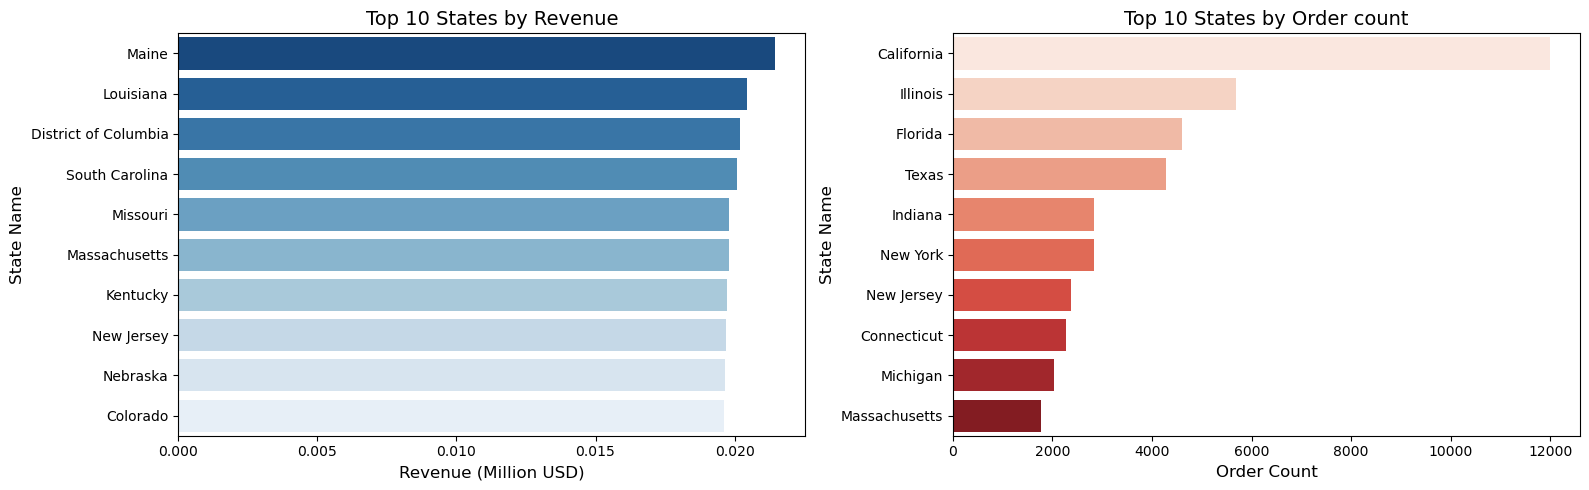

In [212]:
states_by_revenue = df.groupby('state_name')['revenue'].mean().sort_values(ascending=False).head(10)

states_by_order_count = df.groupby('state_name')['order_number'].count().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Top 10 customers by revenue (converted to millions)
sns.barplot(
    x=states_by_revenue.values / 1e6,    # X-axis: revenue in millions
    y=states_by_revenue.index,           # Y-axis: customer names
    palette='Blues_r',         # Color palette (reversed blues)
    ax=axes[0]                 # Draw on the left subplot
)
axes[0].set_title('Top 10 States by Revenue', fontsize=14)         # Title
axes[0].set_xlabel('Revenue (Million USD)', fontsize=12)              # X-axis label
axes[0].set_ylabel('State Name', fontsize=12)                      # Y-axis label

# Plot 2: Bottom 10 customers by revenue (converted to millions)
sns.barplot(
    x=states_by_order_count.values, # X-axis: revenue in millions
    y=states_by_order_count.index,        # Y-axis: customer names
    palette='Reds',            # Color palette (reds)
    ax=axes[1]                 # Draw on the right subplot
)
axes[1].set_title('Top 10 States by Order count', fontsize=14)      # Title
axes[1].set_xlabel('Order Count', fontsize=12)              # X-axis label
axes[1].set_ylabel('State Name', fontsize=12)                      # Y-axis label

# Adjust layout to prevent overlap and display both charts
plt.tight_layout()
plt.show()



### 12. Average Profit Margin by Channel

C:\Users\ankus\AppData\Local\Temp\ipykernel_39532\3610727432.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




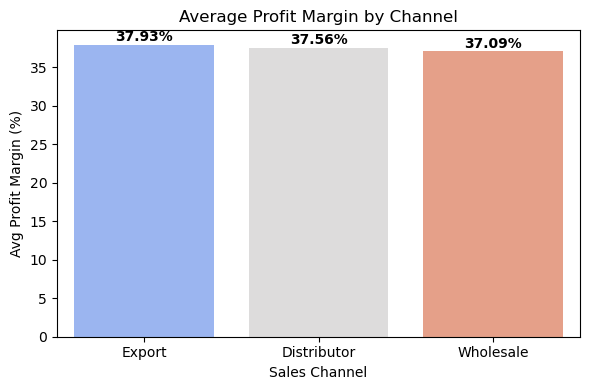

In [215]:
channel_margin = df.groupby('channel')['profit_margin_pct'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))

# 3️⃣ Plot a bar chart of average profit margin by channel
ax = sns.barplot(
    x=channel_margin.index,    # X-axis: channel names
    y=channel_margin.values,   # Y-axis: average profit margin values
    palette='coolwarm'         # Color palette for bars
)

# 4️⃣ Add chart title and axis labels
plt.title('Average Profit Margin by Channel')  # Main title
plt.xlabel('Sales Channel')                    # X-axis label
plt.ylabel('Avg Profit Margin (%)')             # Y-axis label

# 5️⃣ Annotate each bar with its exact margin percentage
for i, v in enumerate(channel_margin.values):
    ax.text(
        i,                  # X position (bar index)
        v + 0.5,            # Y position (bar height + small offset)
        f"{v:.2f}%",        # Text label showing percentage with two decimals
        ha='center',        # Center-align the text horizontally
        fontweight='bold'   # Bold font for readability
    )

plt.tight_layout()
plt.show()

### 13. Top and Bottom 10 Customers by Revenue

C:\Users\ankus\AppData\Local\Temp\ipykernel_39532\3267394181.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




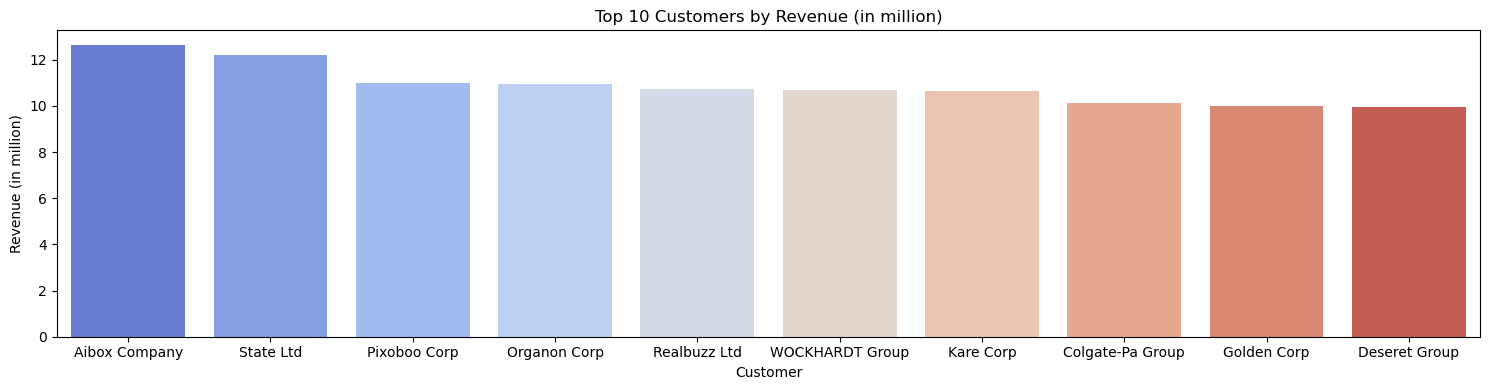

C:\Users\ankus\AppData\Local\Temp\ipykernel_39532\3267394181.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




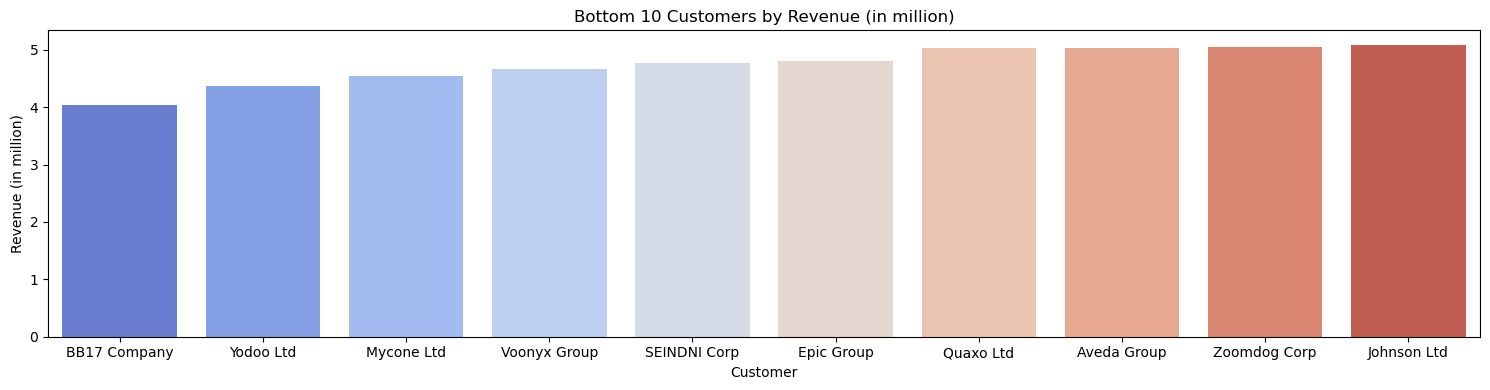

In [222]:
top_cust_by_revenue = df.groupby('customer_name')['revenue'].sum().sort_values(ascending=False).head(10)

bottom_cust_by_revenue = df.groupby('customer_name')['revenue'].sum().sort_values(ascending=True).head(10)

# fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Top 10 customers by revenue (converted to millions)
plt.figure(figsize=(15, 4))
sns.barplot(
    x=top_cust_by_revenue.index,                   # X-axis: state names
    y=top_cust_by_revenue.values / 1e6,        # Y-axis: revenue in millions
    palette='coolwarm'                   # Color palette
)
plt.title('Top 10 Customers by Revenue (in million)')     # Chart title
plt.xlabel('Customer')                              # X-axis label
plt.ylabel('Revenue (in million)')   # Y-axis label
plt.tight_layout()                        # Adjust layout
plt.show()                                # Display the plot

# Plot 2: Top 10 states by number of orders
plt.figure(figsize=(15, 4))
sns.barplot(
    x=bottom_cust_by_revenue.index,                   # X-axis: state names
    y=bottom_cust_by_revenue.values / 1e6,               # Y-axis: order counts
    palette='coolwarm'                   # Color palette
)
plt.title('Bottom 10 Customers by Revenue (in million)')  # Chart title
plt.xlabel('Customer')                              # X-axis label
plt.ylabel('Revenue (in million)')                        # Y-axis label
plt.tight_layout()                               # Adjust layout
plt.show()     

### 14. Customer Segmentation: Revenue vs. Profit Margin

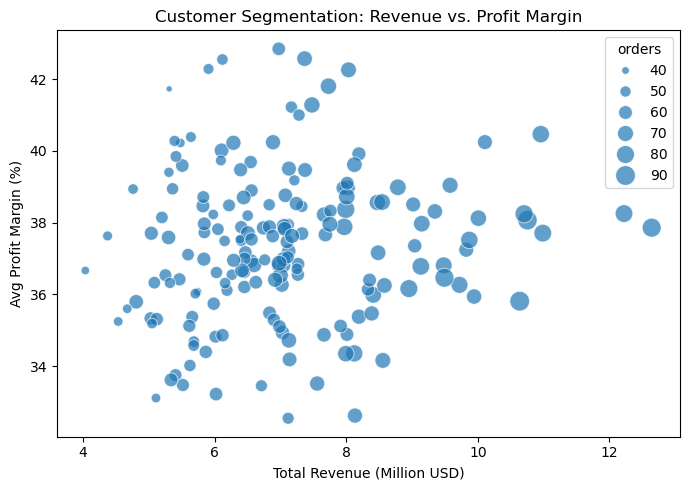

In [228]:
cust_summary = df.groupby('customer_name').agg(
    total_revenue=('revenue', 'sum'),
    avg_profit_margin_pct=('profit_margin_pct', 'mean'),
    orders=('order_number', 'nunique')
).reset_index()

cust_summary['revenue_m']= cust_summary['total_revenue'] / 1e6

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=cust_summary,
    x='revenue_m',        # <-- use revenue in millions
    y='avg_profit_margin_pct',
    size='orders',
    sizes=(20, 200),
    alpha=0.7                              # Point color
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin')
plt.xlabel('Total Revenue (Million USD)')  # <-- updated label
plt.ylabel('Avg Profit Margin (%)')

plt.tight_layout()
plt.show()

### 15. Correlation Heatmap of Numeric Features

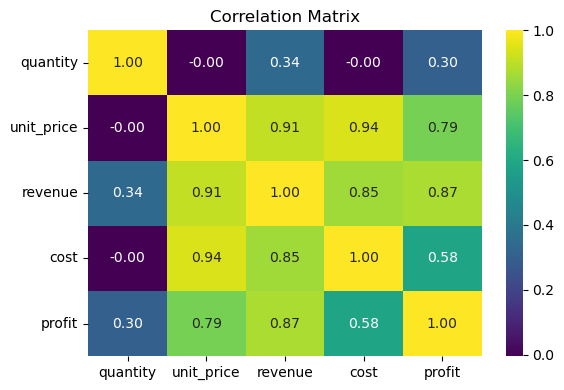

In [230]:
# List numeric columns to include in the correlation calculation
num_cols = ['quantity', 'unit_price', 'revenue', 'cost', 'profit']

# Calculate the correlation matrix for these numeric features
corr = df[num_cols].corr()

# Set the figure size for clarity
plt.figure(figsize=(6,4))

# Plot the heatmap with annotations and a viridis colormap
sns.heatmap(
    corr,           # Data: correlation matrix
    annot=True,     # Display the correlation coefficients on the heatmap
    fmt=".2f",      # Format numbers to two decimal places
    cmap='viridis'  # Color palette for the heatmap
)

# Add title for context
plt.title('Correlation Matrix')

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the heatmap
plt.show()

### **Exporting Final Processed and Cleaned Dataset**

In [232]:
df


,order_number,order_date,customer_name_index,channel,currency_code,warehouse_code,delivery_region_index,product_description_index,quantity,unit_price,...,households,median_income,land_area,water_area,time_zone,us_region,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,52798,36466,268318796,13908113,America/New York,South,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,26020,124759,62489257,386195,America/Los Angeles,West,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,24141,63158,70972793,720300,America/New York,Northeast,NaN,10082.160,8249.040,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,74,Wholesale,USD,AXW291,825,26,12,1815.7,...,18095,69878,26311722,253129,America/New York,Northeast,NaN,11765.736,10022.664,46.0
64100,SO - 0007706,2018-02-28,51,Export,USD,NXH382,444,21,6,864.3,...,26242,71573,35271964,370235,America/Chicago,Midwest,NaN,3474.486,1711.314,33.0
64101,SO - 0007718,2018-02-28,136,Distributor,USD,AXW291,312,13,11,3953.0,...,20651,42786,22943340,594611,America/New York,South,NaN,29133.610,14349.390,33.0
64102,SO - 0008084,2018-02-28,158,Distributor,USD,AXW291,737,20,7,3959.7,...,38912,48662,76228647,162756,America/New York,Northeast,NaN,20511.246,7206.654,26.0


In [233]:
df.to_csv(r"C:\Users\ankus\OneDrive\Desktop\SDE+DATA\DATA\Projects\Sales DA (python+powerBI) end to end\processed_regional_sales_dataset.csv", index=False)